In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!pip install pandas openpyxl

In [4]:
df = pd.read_excel('/content/personal finance data.xlsx')
df.head()

,Date / Time,Mode,Category,Sub category,Income/Expense,Debit/Credit
0,2021-01-01 21:45:00,CUB - online payment,Allowance,From dad,Income,8000.0
1,2021-01-01 21:46:00,CUB - online payment,Food,Snacks,Expense,85.0
2,2021-01-03 18:21:00,CUB - online payment,Other,From dad,Income,500.0
3,2021-01-03 18:22:00,CUB - online payment,Household,Stuffs,Expense,6667.0
4,2021-01-03 18:56:00,CUB - online payment,Transportation,Metro,Expense,30.0


In [8]:


# 2. Check for basic info and missing values
print(df.head())
print(df.info())
print(df.isnull().sum())

# 3. Convert 'Date / Time' to datetime format
df['Date / Time'] = pd.to_datetime(df['Date / Time'])

# 4. Clean column names (remove spaces)
df.columns = df.columns.str.replace(' ', '_')

# 5. Sort by Date / Time
df = df.sort_values('Date_/_Time')

# 6. Create unified 'Amount' column (positive for income, negative for expense)
df['Amount'] = df.apply(
    lambda row: row['Debit/Credit'] if row['Income/Expense'] == 'Income' else -row['Debit/Credit'],
    axis=1
)

# 7. (Optional) Create separate Income and Expense columns
df['Income_Amount'] = df.apply(lambda x: x['Debit/Credit'] if x['Income/Expense'] == 'Income' else 0, axis=1)
df['Expense_Amount'] = df.apply(lambda x: x['Debit/Credit'] if x['Income/Expense'] == 'Expense' else 0, axis=1)

# 8. (Optional) Save the cleaned dataset
df.to_excel('preprocessed_data.xlsx', index=False)

print("Preprocessing complete.")


          Date / Time                  Mode        Category Sub category  \
0 2021-01-01 21:45:00  CUB - online payment       Allowance     From dad   
1 2021-01-01 21:46:00  CUB - online payment            Food       Snacks   
2 2021-01-03 18:21:00  CUB - online payment           Other     From dad   
3 2021-01-03 18:22:00  CUB - online payment       Household       Stuffs   
4 2021-01-03 18:56:00  CUB - online payment  Transportation        Metro   

  Income/Expense  Debit/Credit  
0         Income        8000.0  
1        Expense          85.0  
2         Income         500.0  
3        Expense        6667.0  
4        Expense          30.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date / Time     225 non-null    datetime64[ns]
 1   Mode            225 non-null    object        
 2   Category        225 non-null


Total Income: 698147.0
Total Expense: 149853.28
Net Balance: 548293.72


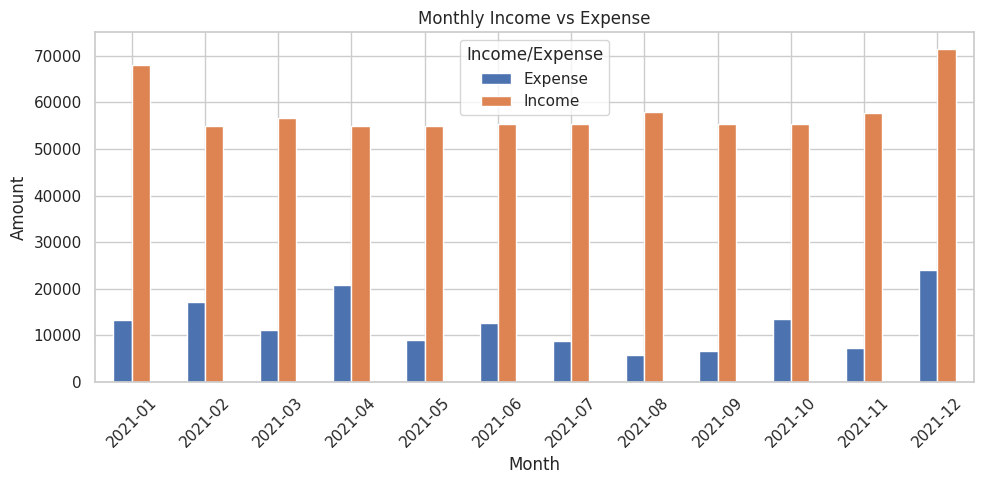

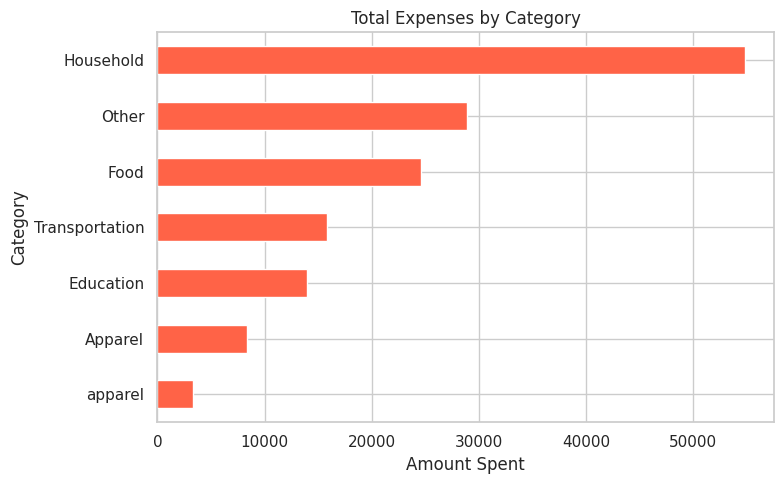

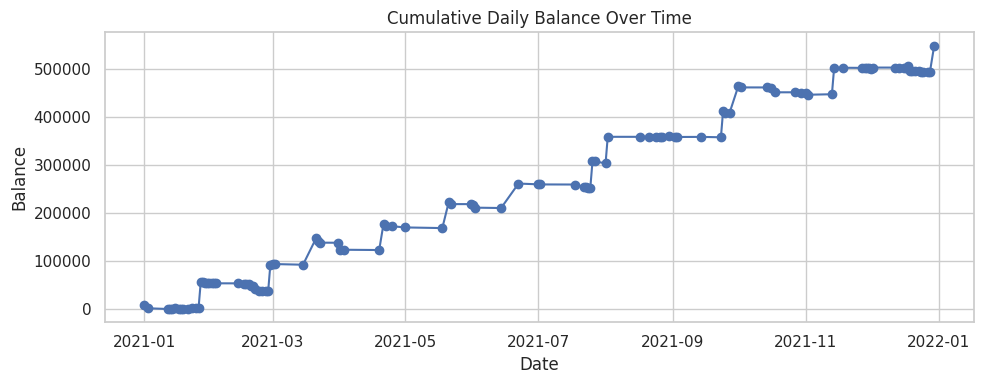

In [14]:


# Load preprocessed Excel file
df = pd.read_excel('/content/preprocessed_data.xlsx')

# Set style for plots
sns.set(style='whitegrid')

# Ensure datetime column is parsed correctly
df['Date_/_Time'] = pd.to_datetime(df['Date_/_Time'])

# Add Month-Year column
df['Month'] = df['Date_/_Time'].dt.to_period('M')

# ========================
# 📌 Basic Stats
# ========================
print("\nTotal Income:", df[df['Income/Expense'] == 'Income']['Debit/Credit'].sum())
print("Total Expense:", df[df['Income/Expense'] == 'Expense']['Debit/Credit'].sum())
print("Net Balance:", df['Amount'].sum())

# ========================
# 📈 Monthly Income vs Expense
# ========================
monthly_data = df.groupby(['Month', 'Income/Expense'])['Debit/Credit'].sum().unstack().fillna(0)

monthly_data.plot(kind='bar', stacked=False, figsize=(10, 5))
plt.title('Monthly Income vs Expense')
plt.ylabel('Amount')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_income_vs_expense.png', dpi=300,bbox_inches='tight')
plt.show()


# ========================
# 🧁 Expense Breakdown by Category
# ========================
expense_data = df[df['Income/Expense'] == 'Expense']
category_totals = expense_data.groupby('Category')['Debit/Credit'].sum().sort_values()

plt.figure(figsize=(8, 5))
category_totals.plot(kind='barh', color='tomato')
plt.title('Total Expenses by Category')
plt.xlabel('Amount Spent')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('expense_breakdown.png',dpi=300, bbox_inches='tight')
plt.show()


# ========================
# 📊 Daily Balance Trend
# ========================
daily_balance = df.groupby(df['Date_/_Time'].dt.date)['Amount'].sum().cumsum()

plt.figure(figsize=(10, 4))
plt.plot(daily_balance.index, daily_balance.values, marker='o', linestyle='-')
plt.title('Cumulative Daily Balance Over Time')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.grid(True)
plt.tight_layout()
plt.savefig('daily_balance_trend.png', dpi=300,bbox_inches='tight')
plt.show()



Cloning into 'finance_analysis'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'finance_analysis'
/content
